# CNN Feature Map 해석

학습된 CNN이 "무엇을 보고 있는지" 시각화해서 읽어봅시다.

- 1층 필터를 그려 모델이 배운 저수준 패턴 보기
- Hook으로 각 층의 출력(Feature Map) 캡처해서 보기
- 다른 클래스 이미지 두 장으로 채널이 어떻게 다르게 켜지는지 비교

- CNN 시각화 영상 : https://youtu.be/pj9-rr1wDhM?si=LV6oB9lmYjZU9Ehm

## 0. 준비 — 학습된 모델 불러오기


In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")


plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('사용 장치:', device)

In [ ]:
# 저장된 가중치(.pth) 를 부어줍니다
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1:  3 → 32 채널, 32×32 → 16×16
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25),
            # Block 2: 32 → 64 채널, 16×16 → 8×8
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25),
            # Block 3: 64 → 128 채널, 8×8 → 4×4
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CNN().to(device)
model.load_state_dict(torch.load('./cnn_model.pth', map_location=device))
model.eval()  # 평가 모드 — Dropout/BatchNorm 비활성화
print('모델 로드 완료')

모델 로드 완료


In [ ]:
# 정규화 버전 — 모델에 넣을 입력
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

test_ds = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform)

# 원본 버전 — 화면에 그릴 때 색이 자연스럽게 나오게
raw_test_ds = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=False, transform=transforms.ToTensor())

classes = ('비행기', '자동차', '새', '고양이', '사슴', '개', '개구리', '말', '배', '트럭')
print('테스트 이미지:', len(test_ds), '장')

테스트 이미지: 10000 장


## 1. 1층 필터 시각화 — 모델이 배운 저수준 패턴

CNN 의 첫 Conv 층은 입력 RGB 이미지와 직접 만나는 층입니다.

- 첫 Conv 가중치 shape: `(32, 3, 3, 3)` — 필터 32개, 각 필터는 RGB × 3×3
- 즉, 각 필터는 RGB 컬러로 그릴 수 있는 작은 그림
- 이 그림이 "이 모델이 배운 저수준 패턴"

필터 텐서 shape: torch.Size([32, 3, 3, 3])


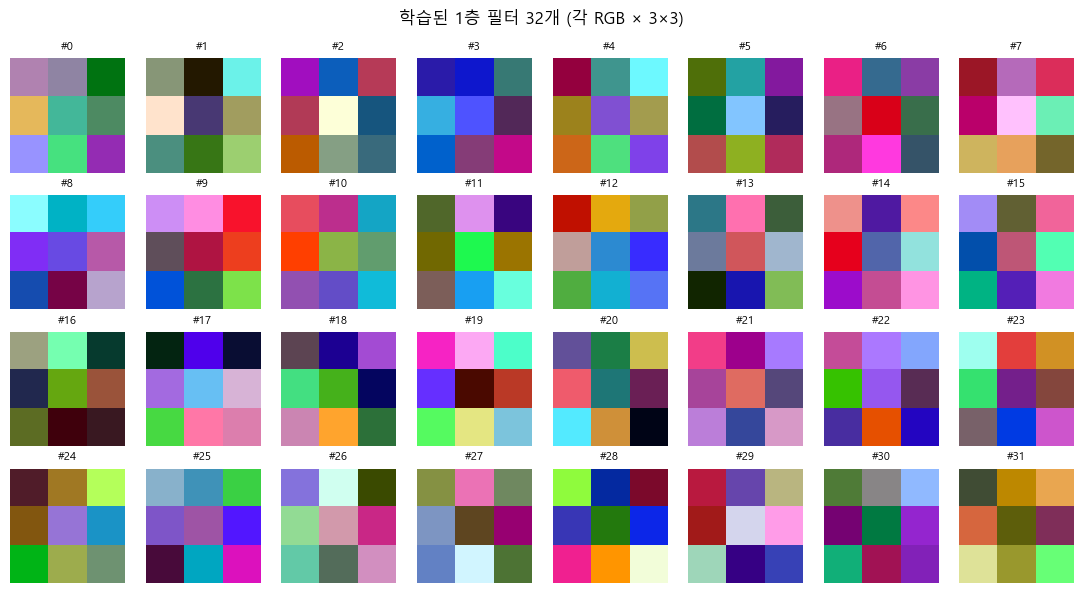

In [ ]:
# 첫 Conv 층의 가중치 꺼내기
weights = model.features[0].weight.detach().cpu()   # (32, 3, 3, 3)
print('필터 텐서 shape:', weights.shape)

# 4행 × 8열 그리드에 32개 필터 그리기
fig, axes = plt.subplots(4, 8, figsize=(11, 6))
for i in range(32):
    ax = axes[i // 8, i % 8]
    f = weights[i]                                  # (3, 3, 3) — RGB, H, W
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)  # 0~1 로 정규화
    f = f.permute(1, 2, 0)                          # (RGB,H,W) → (H,W,RGB)
    ax.imshow(f)
    ax.set_title(f'#{i}', fontsize=8)
    ax.axis('off')
plt.suptitle('학습된 1층 필터 32개 (각 RGB × 3×3)')
plt.tight_layout()
plt.show()

## 2. Feature Map — 입력이 각 층을 통과한 모습

Feature map(특징 맵) = 각 Conv 층의 출력. 그 층의 모든 필터가 입력에 얼마나 반응했는지의 그림입니다.

방법: PyTorch **forward hook** 으로 모델의 중간 출력을 가로채서 저장.

- hook = "이 층을 통과할 때마다 함수를 한번 불러줘" 라고 등록해두는 것
- 모델이 forward 할 때 자동으로 호출됨 → dict 에 출력을 담아둠 → 시각화

In [ ]:
# 각 층 출력을 담을 dict
feature_maps = {}

# 각 블록 첫 Conv 의 출력을 잡아주는 함수 3개
def save_block1(module, inp, out):
    feature_maps['block1'] = out.detach().cpu()

def save_block2(module, inp, out):
    feature_maps['block2'] = out.detach().cpu()

def save_block3(module, inp, out):
    feature_maps['block3'] = out.detach().cpu()

# features 의 인덱스는 위 CNN 정의 순서 기준
#   features[0]  = Block1 첫 Conv (3 → 32)
#   features[7]  = Block2 첫 Conv (32 → 64)
#   features[14] = Block3 첫 Conv (64 → 128)
h1 = model.features[0].register_forward_hook(save_block1)
h2 = model.features[7].register_forward_hook(save_block2)
h3 = model.features[14].register_forward_hook(save_block3)
print('Hook 등록 완료')

Hook 등록 완료


In [ ]:
# 테스트셋 7번 이미지를 한번 모델에 통과시켜 활성화 캡처
sample_idx = 7
img_norm, label = test_ds[sample_idx]    # 정규화 버전 — 모델 입력용
img_raw, _ = raw_test_ds[sample_idx]     # 원본 — 화면에 보여줄 용

# unsqueeze(0) — (3, 32, 32) 에 배치 차원 추가 → (1, 3, 32, 32)
with torch.no_grad():
    model(img_norm.unsqueeze(0).to(device))

# hook 이 자동 호출돼서 dict 에 들어가 있음
for name, act in feature_maps.items():
    print(f'{name}: {tuple(act.shape)}')

block1: (1, 32, 32, 32)
block2: (1, 32, 16, 16)
block3: (1, 64, 8, 8)


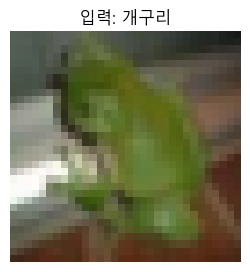

In [ ]:
# 어떤 이미지를 넣었는지 먼저 보기
plt.figure(figsize=(3, 3))
plt.imshow(img_raw.permute(1, 2, 0))    # (3, 32, 32) → (32, 32, 3)
plt.title(f'입력: {classes[label]}')
plt.axis('off')
plt.show()

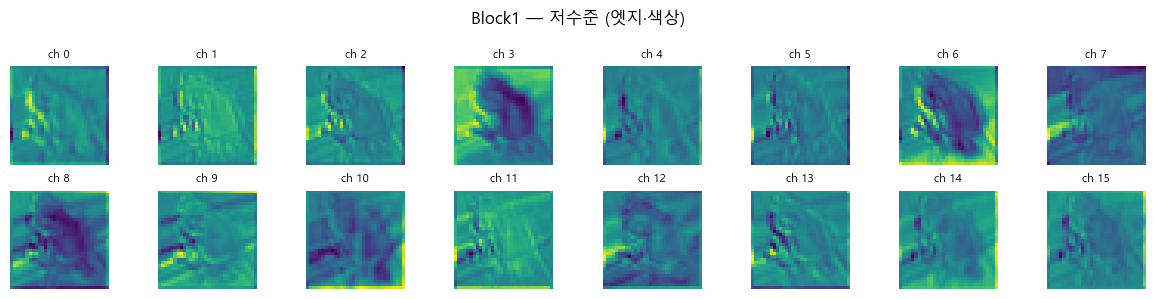

In [ ]:
# Block1 — 채널 32개 중 앞 16개
act = feature_maps['block1'][0]   # (32, 32, 32) — 채널 32개, 공간 32×32

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(16):
    ax = axes[i // 8, i % 8]
    ax.imshow(act[i].numpy(), cmap='viridis')   # 한 채널 = 2D 배열
    ax.set_title(f'ch {i}', fontsize=8)
    ax.axis('off')
plt.suptitle('Block1 — 저수준 (엣지·색상)')
plt.tight_layout()
plt.show()

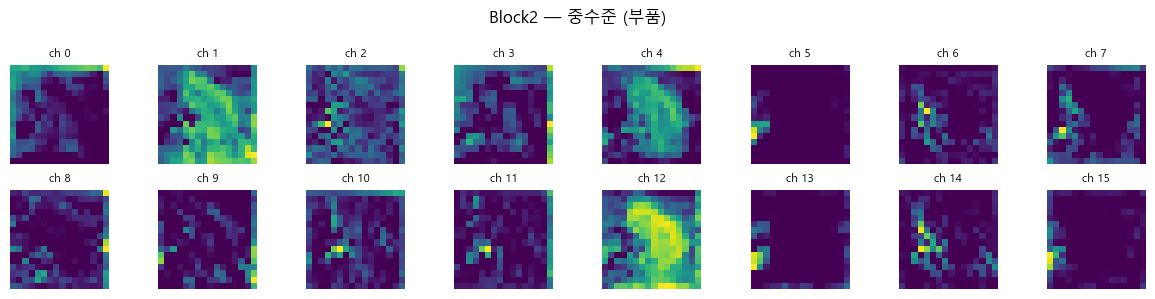

In [ ]:
# Block2 — 채널 64개 중 앞 16개
act = feature_maps['block2'][0]   # (64, 16, 16)

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(16):
    ax = axes[i // 8, i % 8]
    ax.imshow(act[i].numpy(), cmap='viridis')
    ax.set_title(f'ch {i}', fontsize=8)
    ax.axis('off')
plt.suptitle('Block2 — 중수준 (부품)')
plt.tight_layout()
plt.show()

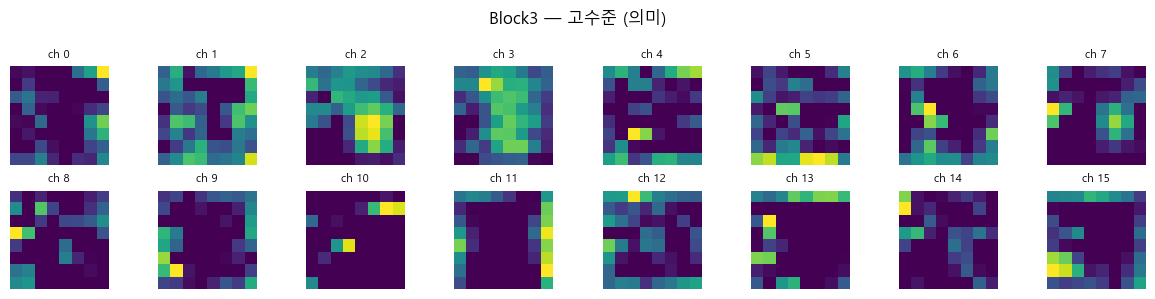

In [ ]:
# Block3 — 채널 128개 중 앞 16개
act = feature_maps['block3'][0]   # (128, 4, 4)

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(16):
    ax = axes[i // 8, i % 8]
    ax.imshow(act[i].numpy(), cmap='viridis')
    ax.set_title(f'ch {i}', fontsize=8)
    ax.axis('off')
plt.suptitle('Block3 — 고수준 (의미)')
plt.tight_layout()
plt.show()

## 3. Feature Map 어떻게 읽나

처음 보면 노란/보라 얼룩이라 막막합니다. 세 가지 원칙으로 읽으면 됩니다.

**원칙 1 — 각 채널 = 학습된 패턴 감지기**
- 채널 한 개 = 학습된 필터 한 개의 응답
- **밝은 픽셀** = 그 위치에서 필터의 패턴이 발견됨
- **어두운 픽셀** = 그 패턴 거의 없음

**원칙 2 — 깊어질수록 의미가 추상화**

| 층 | 무엇 | 시각적으로 |
|---|---|---|
| Block 1 | 엣지·색상 | 원본 형태가 거의 보임 |
| Block 2 | 작은 부품 (바퀴·눈·날개) | 윤곽 흐림, 의미 단위로 모임 |
| Block 3 | 객체·의미 | 4×4 까지 줄어 거의 추상 |

**원칙 3 — 까만 (dead) 채널은 정상**
- 한 이미지에 모든 패턴이 있을 리 없음
- "빨간 원"을 잡는 채널은, 빨간 원이 없는 입력에선 까맣게 나옴
- 다른 입력 (빨간 사과) 을 넣으면 그 채널이 환해짐

## 4. 두 클래스 비교 — 같은 채널이 다르게 켜진다

같은 모델에 다른 클래스 이미지 두 장을 넣어 채널이 어떻게 다르게 반응하는지 봅시다. 이게 CNN 이 클래스를 구분하는 메커니즘입니다.

In [ ]:
# 자동차(1) 와 새(2) 의 첫번째 샘플 찾기
for i in range(len(test_ds)):
    if test_ds[i][1] == 1:
        car_norm, _ = test_ds[i]
        car_raw, _ = raw_test_ds[i]
        break

for i in range(len(test_ds)):
    if test_ds[i][1] == 2:
        bird_norm, _ = test_ds[i]
        bird_raw, _ = raw_test_ds[i]
        break

# 자동차 통과 → Block1 활성화 복사 (다음 forward 가 덮어쓰니까)
with torch.no_grad():
    model(car_norm.unsqueeze(0).to(device))
car_act = feature_maps['block1'][0].clone()

# 새 통과 → Block1 활성화 복사
with torch.no_grad():
    model(bird_norm.unsqueeze(0).to(device))
bird_act = feature_maps['block1'][0].clone()

print('car_act:', tuple(car_act.shape), '| bird_act:', tuple(bird_act.shape))

car_act: (32, 32, 32) | bird_act: (32, 32, 32)


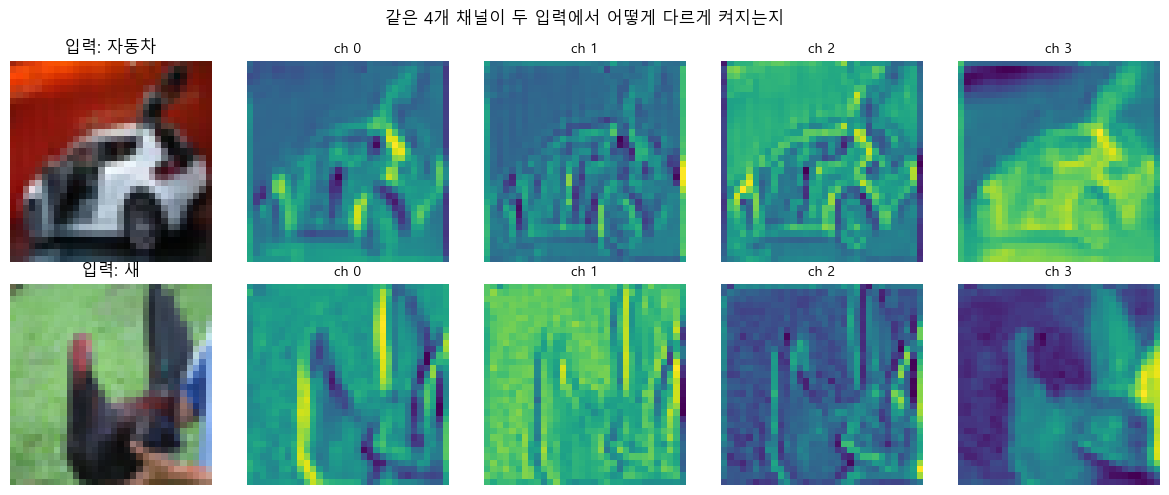

In [ ]:
# 두 이미지 + Block1 채널 4개씩 = 2행 5열
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# 1행: 자동차
axes[0, 0].imshow(car_raw.permute(1, 2, 0))
axes[0, 0].set_title('입력: 자동차')
axes[0, 0].axis('off')
for ci in range(4):
    axes[0, ci + 1].imshow(car_act[ci].numpy(), cmap='viridis')
    axes[0, ci + 1].set_title(f'ch {ci}', fontsize=10)
    axes[0, ci + 1].axis('off')

# 2행: 새
axes[1, 0].imshow(bird_raw.permute(1, 2, 0))
axes[1, 0].set_title('입력: 새')
axes[1, 0].axis('off')
for ci in range(4):
    axes[1, ci + 1].imshow(bird_act[ci].numpy(), cmap='viridis')
    axes[1, ci + 1].set_title(f'ch {ci}', fontsize=10)
    axes[1, ci + 1].axis('off')

plt.suptitle('같은 4개 채널이 두 입력에서 어떻게 다르게 켜지는지')
plt.tight_layout()
plt.show()

In [ ]:
# Hook 정리 — 이후 일반 추론에 영향 안 가도록
h1.remove()
h2.remove()
h3.remove()
print('Hook 해제')

Hook 해제


## 정리

- **1층 필터**는 RGB 3×3 커널로 직접 그림 — 학습된 저수준 패턴이 보임
- **Feature Map** 은 forward hook 으로 가로채서 그림 — 채널마다 다른 패턴을 감지
- 세 가지 원칙으로 읽기:
  1. 채널 = 패턴 감지기 · 밝음 = 발견됨
  2. 깊은 층일수록 추상 (엣지 → 부품 → 의미)
  3. 까만 채널은 정상 — 그 패턴이 입력에 없을 뿐
- 다른 클래스 이미지 두 장으로 같은 채널이 다르게 켜지는 걸 보면 CNN 의 작동을 직관적으로 이해할 수 있습니다